### **Trabalho Final da Disciplina - Introdução ao Aprendizado de Máquina**

**Prever churn - Rotatividade de clientes no setor de telecomunicações**



---


Aluna: Natasha Sales Ferreira Pinto (CP3025799)

Professor: Everton Meyer da Silva





### **1. Especificação do Projeto: Previsão de Churn**

**1.1. Descrição e Motivação do Problema**

O principal problema é a perda de clientes (Churn) em uma empresa de telecomunicações. O objetivo é identificar antecipadamente quais clientes têm maior probabilidade de cancelar seus serviços.

Motivação: Reter um cliente antigo é muito mais barato do que adquirir um novo. Para empresas de serviços por assinatura (telecom, streaming...), o Churn alto impacta diretamente a sustentabilidade do negócio.

Impactos: A redução do churn estabiliza a receita recorrente (MRR), melhora o LTV (Lifetime Value) e orienta melhorias nos serviços que apresentam maior índice de rejeição.

**1.2. Descrição da Base de Dados**

A base utilizada é o dataset Telco Customer Churn. (Fonte: Kaggle - Telco Customer Churn.)

Nessa base de dados, cada linha representa um cliente individual da empresa de telecomunicações, contendo suas informações demográficas, serviços contratados, dados financeiros e se ele abandonou ou não a empresa no último mês.

**Principais atributos:**

**customerID:** Identificador único do cliente (Categórico (ID))

**tenure:**	Meses que o cliente está na empresa	(Numérico (Inteiro))

**MonthlyCharges:**	Valor cobrado mensalmente	(Numérico (Float))

**TotalCharges:**	Valor total cobrado do cliente	(Numérico (Float*))

**Contract:**	Tipo de contrato	(Categórico)

**Churn:**	Variável Alvo (Categórico (Binário))

**1.3. Hipóteses e Perguntas de Pesquisa**

Hipóteses iniciais:

H1 - Fidelidade: Clientes com contratos mensais ("Month-to-month") cancelam mais do que aqueles com contratos de longo prazo?

H2 - Serviços de Valor: A falta de suporte técnico (TechSupport) está correlacionada a uma taxa maior de cancelamento?

H3 - Impacto Financeiro: Clientes com cobranças mensais (MonthlyCharges) mais altas tendem a abandonar o serviço com mais frequência?

H4 - Tempo de Casa: Clientes novos (baixo tenure) representam a maior parte do churn?

In [1]:
# ETAPA 1: PREPARAÇÃO DA BASE DE DADOS!

import pandas as pd

# 1. carregamento dos dados
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 2. verificação de Duplicatas
print(f"Quantidade de linhas duplicadas: {df.duplicated().sum()}")

# 3. limpeza
# remove o ID que não serve para análise estatística
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

# converte colunas financeiras para numérico
# (errors='coerce' gera NaNs em espaços vazios)
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 4. tratamento de dados faltantes
print(f"Nulos encontrados após conversão:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.dropna(inplace=True)

# 5. verificação final
print("\n--- Dados carregados e limpos com sucesso! ---")
print(f"Formato final do dataset: {df.shape}")
df.info()

Quantidade de linhas duplicadas: 0
Nulos encontrados após conversão:
TotalCharges    11
dtype: int64

--- Dados carregados e limpos com sucesso! ---
Formato final do dataset: (7032, 20)
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  St

### **2. Preparação da Base de Dados (Limpeza Inicial)**

**2.1. Dificuldades e Ajustes de Tipos**

A principal dificuldade encontrada foi a importação incorreta das colunas financeiras MonthlyCharges e TotalCharges, porque embora contenham valores monetários, foram lidas como texto (object). Isso aconteceu devido à presença de caracteres invisíveis e espaços em branco (" ") em registros onde o valor não estava preenchido.
A solução foi utilizar a função pd.to_numeric com o parâmetro errors='coerce', que forçou a conversão para float64, transformando os espaços vazios em valores nulos (NaN) tratáveis.

**2.2. Dados Faltantes e Tratamento**

Após a conversão correta dos tipos, identifiquei 11 valores faltantes na coluna TotalCharges e optei pela remoção das linhas correspondentes, pois como o dataset possui mais de 7.000 registros, a exclusão de apenas 11 linhas representa uma perda insignificante (aproximadamente 0,15% dos dados) e evita a inserção de ruído por técnicas de imputação (como média ou mediana) em variáveis financeiras sensíveis.

**2.3.Remoção de Duplicatas e Ruídos**

Verifiquei a existência de linhas duplicadas, mas o dataset apresentou registros únicos para cada cliente. A coluna customerID foi removida. Por ser um identificador alfanumérico aleatório, ela não possui valor estatístico para a previsão de Churn e poderia causar ruído no treinamento do modelo.

**2.4. Outliers**
Nesta fase inicial, não foram removidos outliers. As distribuições de cobranças e tempo de permanência (tenure) seguem intervalos plausíveis para o setor de telecomunicações.



### **3. Análise Exploratória de Dados (EDA)**

**3.1. Parte A: Percepções Gerais (Univariadas)**

1 - Qual a proporção de clientes que abandonaram a empresa (Churn)?

Utilizar o Gráfico de Barras é ideal para visualizar a composição da variável alvo e identificar desbalanceamento.


2 - Qual o perfil de permanência (tenure) dos clientes?

Utilizar  um Histograma pois permite ver a concentração de clientes novos vs. antigos.



3 - Quais são os métodos de pagamento mais comuns?

Utilizar um Gráfico de barras horizontais deve ser util para identificar o comportamento financeiro predominante.


4 - Como estão distribuídos os gastos mensais (MonthlyCharges)?

Utilizar o Boxplot é adequado para identificar a mediana dos gastos e a presença de valores discrepantes (outliers).



**3.2. Parte B: Relações entre Variáveis (Multivariadas)**

5 - O tipo de contrato influencia diretamente o Churn?

A hipótese é de que clientes com contratos mensais têm uma taxa de churn muito superior. Para justificar, serão utilizadas Barras Empilhadas (Stacked Bar). Excelente para comparar proporções entre categorias.

6 - Clientes que pagam mais caro saem com mais frequência?

A hipótese é que O churn é maior em faixas de preço elevadas. A justificativa será provada com um Gráfico de Densidade (KDE Plot) que permite ver onde as distribuições de quem saiu e quem ficou se sobrepõem e onde se distanciam.




7 - A oferta de Suporte Técnico (TechSupport) ajuda na retenção?

A hipótese é de que clientes sem suporte técnico dão mais churn. Para justificar, o Gráfico de Barras Agrupadas irá facilitar a comparação direta entre grupos de serviço.



8 - Existe correlação forte entre o tempo de casa e o total gasto?

A hipótese é que existe sim uma correlação positiva forte, mas o churn pode estar concentrado em quem tem gasto alto e pouco tempo de casa. A Matriz de Correlação (Heatmap) é a melhor forma de visualizar a força da relação entre todas as variáveis numéricas simultaneamente.


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# estilo visual limpo para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

/tmp/ipykernel_19577/3106884483.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette='viridis')


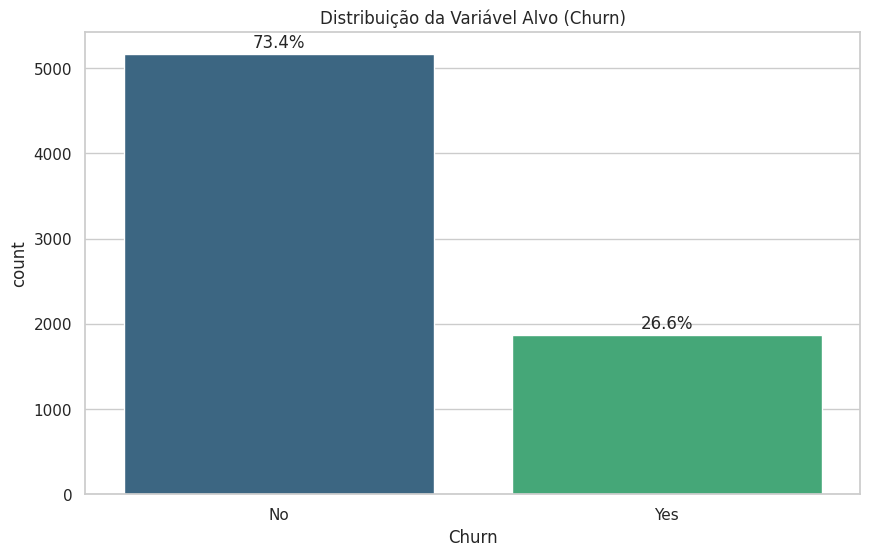

In [3]:
# Proporção de Churn

# verificar o desbalanceamento da variável alvo
ax = sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribuição da Variável Alvo (Churn)')

# calcular e exibir a porcentagem em cima das barras para análise quantitativa direta
total_clientes = len(df)
for p in ax.patches:
    porcentagem = f'{100 * p.get_height() / total_clientes:.1f}%'
    ax.annotate(porcentagem, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, xytext=(0, 5), textcoords='offset points')
plt.show()

A base de dados apresenta um desbalanceamento entre as classes: cerca de 26.6% dos clientes cancelaram o serviço (Yes), enquanto 73.4% permaneceram (No). Isso indica que, embora a maioria seja fiel, a taxa de churn é significativa e precisa de estratégias de retenção, especialmente porque o custo de aquisição de novos clientes é geralmente mais alto que o de manutenção.

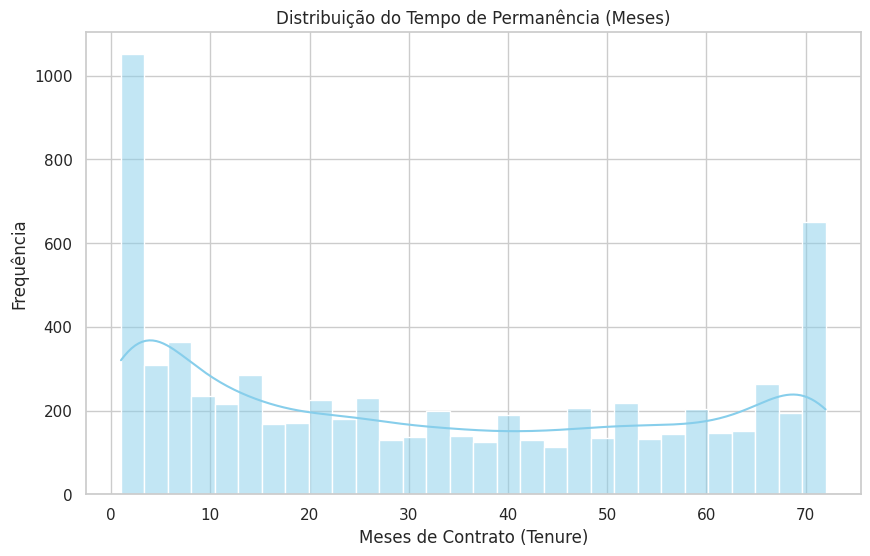

In [4]:
# Perfil de Permanência (Tenure)

# O histograma com KDE (linha de densidade) ajuda a visualizar a concentração de clientes
sns.histplot(df['tenure'], kde=True, color='skyblue', bins=30)
plt.title('Distribuição do Tempo de Permanência (Meses)')
plt.xlabel('Meses de Contrato (Tenure)')
plt.ylabel('Frequência')
plt.show()

O histograma revela uma distribuição com dois picos principais: um grande volume de clientes novos (com menos de 5 meses de casa) e um grupo consolidado de clientes antigos (acima de 60 meses). Isso sugere que a empresa consegue reter clientes no longo prazo, mas enfrenta dificuldades críticas na fase de "onboarding" ou nos primeiros meses de contrato.

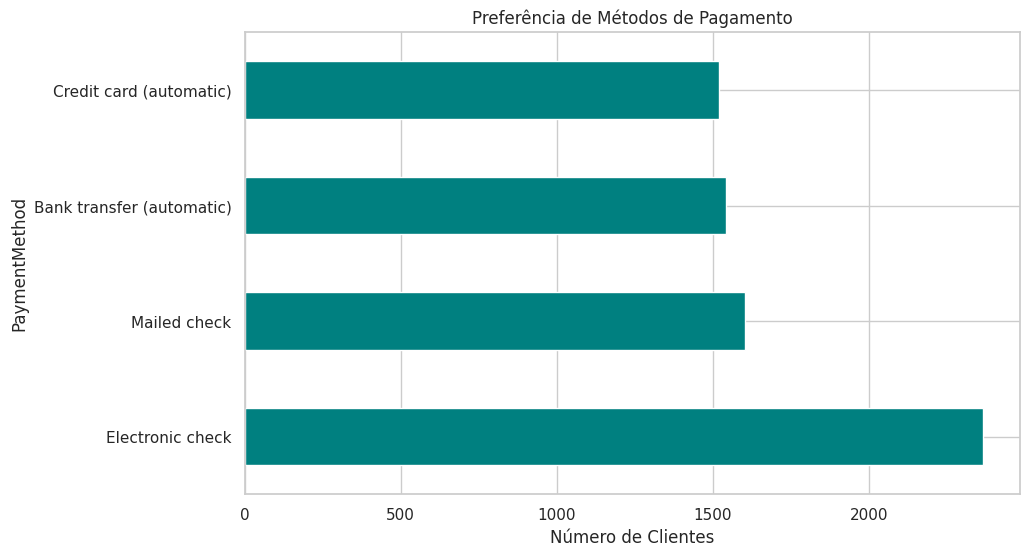

In [5]:
# Métodos de Pagamento

# barras horizontais para acomodar melhor os nomes longos das categorias
df['PaymentMethod'].value_counts().plot(kind='barh', color='teal')
plt.title('Preferência de Métodos de Pagamento')
plt.xlabel('Número de Clientes')
plt.show()

O método "Electronic check" é o mais utilizado, mas análises prévias indicam que ele costuma estar associado a maiores taxas de cancelamento. Métodos automáticos (cartão de crédito e transferência bancária) são menos frequentes, o que representa uma oportunidade para a empresa incentivar formas de pagamento mais estáveis.

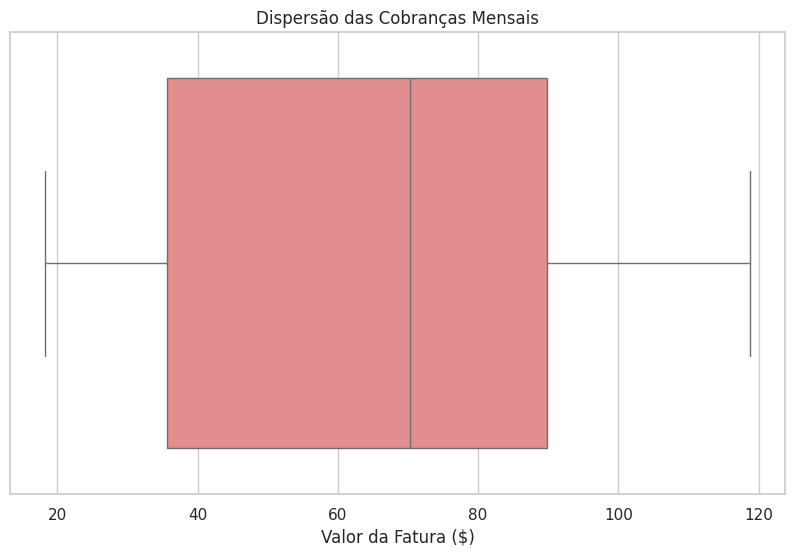

In [6]:
# Gastos Mensais

# o Boxplot é essencial para identificar a mediana e se há valores muito fora do padrão (outliers)
sns.boxplot(x=df['MonthlyCharges'], color='lightcoral')
plt.title('Dispersão das Cobranças Mensais')
plt.xlabel('Valor da Fatura ($)')
plt.show()

O boxplot mostra que a mediana das cobranças mensais gira em torno de $70. Não foram detectados outliers (valores absurdos), o que indica que os dados de cobrança são consistentes. A amplitude sugere que a empresa possui uma cartela variada de clientes, desde planos básicos até pacotes premium.

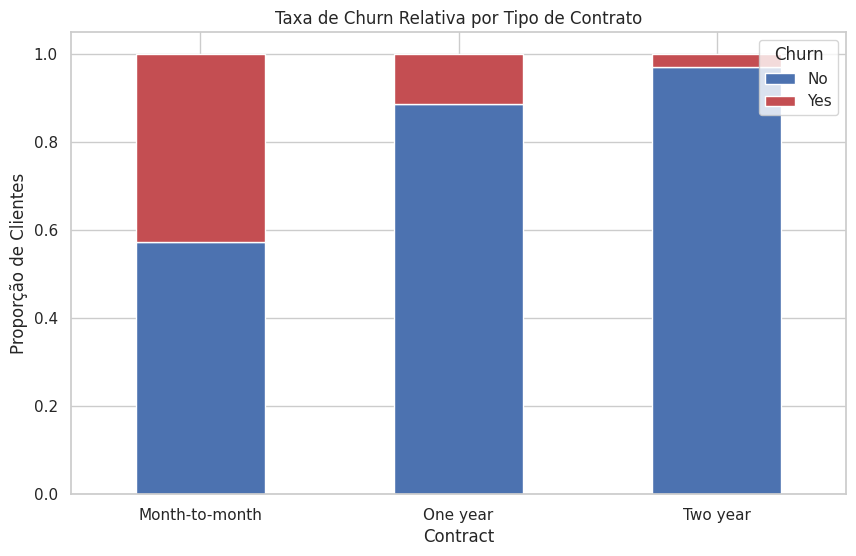

In [7]:
# Tipo de Contrato vs Churn

# tabela de frequências normalizada para comparar proporções (0 a 1)
# isso evita que o volume maior de contratos mensais mascare a taxa real de cancelamento
tabela_contrato = pd.crosstab(df['Contract'], df['Churn'], normalize='index')

tabela_contrato.plot(kind='bar', stacked=True, color=['#4C72B0', '#C44E52'])
plt.title('Taxa de Churn Relativa por Tipo de Contrato')
plt.ylabel('Proporção de Clientes')
plt.xticks(rotation=0) # mantém os nomes dos contratos na horizontal
plt.legend(title='Churn', loc='upper right')
plt.show()


Este gráfico confirma a hipótese principal: clientes com contrato "Month-to-month" possuem uma propensão ao churn drasticamente superior aos contratos anuais. A flexibilidade do contrato mensal facilita a saída, sugerindo que estratégias de fidelização (como descontos para contratos de longo prazo) são essenciais para reduzir a rotatividade.

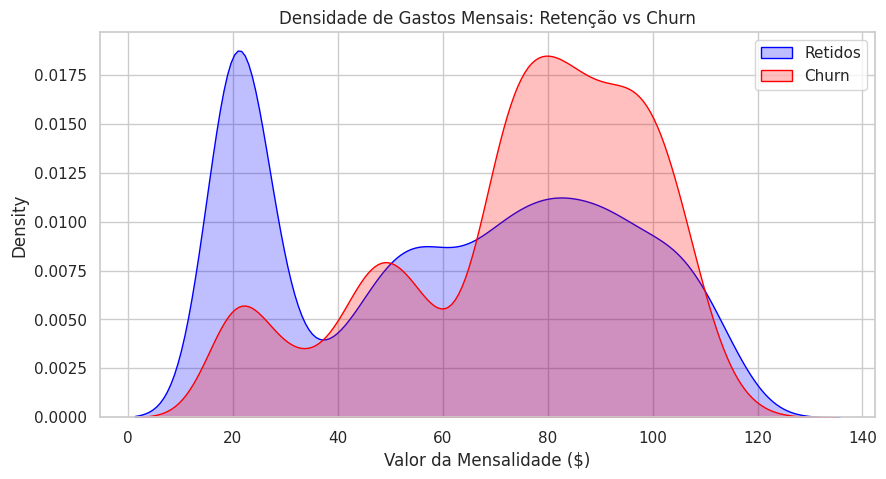

In [8]:
# Gastos Mensais vs Churn

# o KDE plot segmentado permite ver se o Churn aumenta em faixas específicas de preço
plt.figure(figsize=(10, 5))
sns.kdeplot(df[df['Churn']=='No']['MonthlyCharges'], label='Retidos', fill=True, color='blue')
sns.kdeplot(df[df['Churn']=='Yes']['MonthlyCharges'], label='Churn', fill=True, color='red')
plt.title('Densidade de Gastos Mensais: Retenção vs Churn')
plt.xlabel('Valor da Mensalidade ($)')
plt.legend()
plt.show()

O gráfico de densidade revela que o grupo de churn (linha vermelha) tem uma concentração muito alta em faturas na faixa de 70 a 100. Isso sugere que clientes que pagam valores mais altos sentem mais o impacto financeiro e podem estar mais propensos a buscar concorrentes com preços menores, indicando uma possível falta de percepção de valor nos planos mais caros.

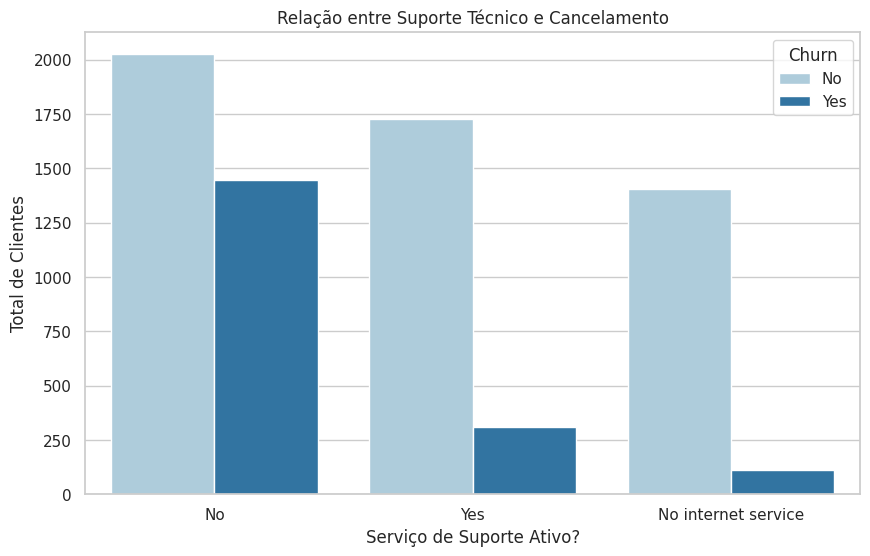

In [9]:
# Suporte Técnico vs Churn

# comparação entre grupos para validar se serviços de suporte auxiliam na retenção
sns.countplot(x='TechSupport', hue='Churn', data=df, palette='Paired')
plt.title('Relação entre Suporte Técnico e Cancelamento')
plt.xlabel('Serviço de Suporte Ativo?')
plt.ylabel('Total de Clientes')
plt.show()

Clientes que não possuem suporte técnico apresentam um índice de cancelamento muito maior. Isso valida a hipótese de que o suporte atua como um serviço de valor agregado que aumenta a satisfação e a segurança do usuário. A ausência de auxílio técnico deixa o cliente mais vulnerável a abandonar o serviço diante de qualquer problema.

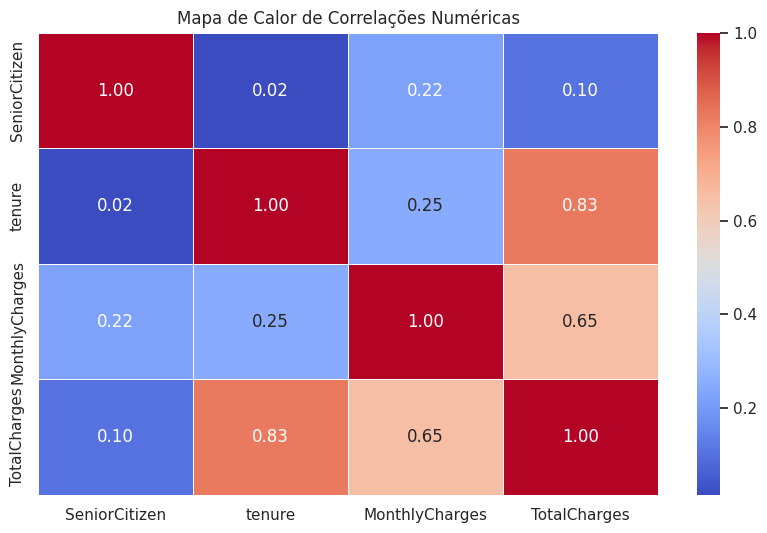

In [10]:
# Matriz de Correlação

# correlação de Pearson apenas para colunas numéricas
correlacoes_numericas = df.corr(numeric_only=True)

# o mapa de calor (Heatmap) resume as relações lineares de forma visual e rápida
sns.heatmap(correlacoes_numericas, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlações Numéricas')
plt.show()

A matriz de correlação mostra uma forte relação positiva (0.83) entre tenure e TotalCharges, o que é esperado (quanto mais tempo o cliente fica, mais ele gasta no total). Nota-se também que MonthlyCharges tem correlação moderada com TotalCharges, mas baixa com o tenure, indicando que o preço mensal não depende necessariamente do tempo de contrato do cliente.

### **4. Síntese Crítica dos Achados (Conclusão da EDA)**

**4.1. Interpretações e Principais Achados**

O "Perfil de Risco": O cliente com maior propensão ao churn é aquele que possui contrato mensal (Month-to-month), utiliza serviços de Fibra Óptica e não contratou serviços de suporte adicional, como o TechSupport.

A "Janela Crítica": O churn é extremamente acentuado nos primeiros 12 meses de contrato (baixo tenure). Clientes que superam a barreira dos 24 meses tendem a apresentar uma fidelidade muito maior.

Sensibilidade ao Preço: Identificamos um aumento na densidade de cancelamentos em faixas de cobrança mensal entre 70 e 100, sugerindo que o valor da fatura é um fator determinante para a saída do cliente.

**4.2. Possíveis Implicações para o Negócio**

Estratégia de Retenção: A empresa deve focar em campanhas de incentivo para migração de contratos mensais para anuais (ex: descontos progressivos), visando aumentar o custo de saída e a percepção de valor.

Atenção à Fibra Óptica: É necessário investigar a qualidade do serviço de Fibra Óptica ou a competitividade de seu preço, dado que ele apresenta proporcionalmente mais churn que o serviço DSL.

Onboarding: Implementar um acompanhamento mais próximo (Customer Success) nos primeiros 6 meses de vida do cliente pode reduzir drasticamente a evasão precoce.

**4.3. Limitações Observadas no Dataset**

Ausência de Variáveis de Satisfação: O dataset não contém métricas como NPS (Net Promoter Score) ou histórico de chamados no suporte, o que impede saber se o churn foi motivado por uma experiência ruim pontual.

Dados Temporais: Por ser um recorte estático (snapshot), não conseguimos observar a sazonalidade (ex: se o churn aumenta em determinados meses do ano).

Concorrência: Não há dados sobre a presença de concorrentes na região do cliente, um fator externo que influencia fortemente a decisão de cancelamento.





